# 00 — Dataset Preprocessing & Exploration

**Shared notebook — run once before any model training. No training code here.**

### Dataset structure
```
train/
    fruit/       apple  banana  grapes  kiwi  mango  pineapple  pomegranate  watermelon
    vegetable/   beetroot  bell pepper  cabbage  capsicum  carrot  cauliflower  ...  (28 classes)
test/
    fruit/       (same class names; orange appears here instead of under vegetable/)
    vegetable/   (same class names)
validation/      IGNORED — flat structure, not used
```

**36 total classes.**  
The `fruit/` and `vegetable/` sub-folders are a grouping layer only — all generators
flatten them so the model sees 36 classes directly.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f'Python     : {sys.version.split()[0]}')
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')

Python     : 3.10.0
TensorFlow : 2.21.0
NumPy      : 2.2.6
Pandas     : 2.3.3


In [2]:
ROOT       = Path('.')
TRAIN_ROOT = ROOT / 'train'
TEST_ROOT  = ROOT / 'test'
IMG_SIZE   = (224, 224)   # shared input size for MobileNetV2, ResNet50, EfficientNetB0
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

assert TRAIN_ROOT.exists(), 'train/ not found — run notebook from project root'
assert TEST_ROOT.exists(),  'test/  not found — run notebook from project root'
print(f'TRAIN_ROOT : {TRAIN_ROOT.resolve()}')
print(f'TEST_ROOT  : {TEST_ROOT.resolve()}')

TRAIN_ROOT : C:\final projects\sem 8\Fruits_Vegetables_Classification_DL\train
TEST_ROOT  : C:\final projects\sem 8\Fruits_Vegetables_Classification_DL\test


## 1. Directory Structure

In [3]:
for cat in sorted(TRAIN_ROOT.iterdir()):
    if not cat.is_dir():
        continue
    print(f'train/{cat.name}/')
    for cls_dir in sorted(cat.iterdir()):
        if cls_dir.is_dir():
            n = sum(1 for f in cls_dir.iterdir()
                    if f.is_file() and f.suffix.lower() in IMG_EXTS)
            print(f'  {cls_dir.name:<22s} {n:>4d} images')

train/fruit/
  apple                    68 images
  banana                   75 images
  grapes                  100 images
  kiwi                     88 images
  mango                    86 images
  pineapple                99 images
  pomegranate              79 images
  watermelon               84 images
train/vegetable/
  beetroot                 88 images
  bell pepper              90 images
  cabbage                  92 images
  capsicum                 89 images
  carrot                   82 images
  cauliflower              79 images
  chilli pepper            87 images
  corn                     87 images
  cucumber                 94 images
  eggplant                 84 images
  garlic                   92 images
  ginger                   68 images
  jalepeno                 88 images
  lemon                    82 images


  lettuce                  97 images


  onion                    94 images
  orange                   69 images
  paprika                  83 images
  pear                     89 images
  peas                    100 images
  potato                   77 images
  raddish                  81 images
  soy beans                97 images
  spinach                  97 images
  sweetcorn                91 images
  sweetpotato              69 images
  tomato                   92 images
  turnip                   98 images


## 2. Class Inventory

In [4]:
def discover_classes(root: Path) -> dict:
    """Flatten fruit/vegetable grouping layer -> {class_name: path}."""
    classes = {}
    for cat_dir in sorted(root.iterdir()):
        if not cat_dir.is_dir():
            continue
        for cls_dir in sorted(cat_dir.iterdir()):
            if cls_dir.is_dir():
                classes[cls_dir.name.lower()] = cls_dir
    return classes

train_classes = discover_classes(TRAIN_ROOT)
test_classes  = discover_classes(TEST_ROOT)
CLASS_NAMES   = sorted(train_classes.keys())
N_CLASSES     = len(CLASS_NAMES)
CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Train classes : {len(train_classes)}')
print(f'Test  classes : {len(test_classes)}')
print(f'\nCLASS_NAMES ({N_CLASSES} total):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i:2d}  {name}')

Train classes : 36
Test  classes : 36

CLASS_NAMES (36 total):
   0  apple
   1  banana
   2  beetroot
   3  bell pepper
   4  cabbage
   5  capsicum
   6  carrot
   7  cauliflower
   8  chilli pepper
   9  corn
  10  cucumber
  11  eggplant
  12  garlic
  13  ginger
  14  grapes
  15  jalepeno
  16  kiwi
  17  lemon
  18  lettuce
  19  mango
  20  onion
  21  orange
  22  paprika
  23  pear
  24  peas
  25  pineapple
  26  pomegranate
  27  potato
  28  raddish
  29  soy beans
  30  spinach
  31  sweetcorn
  32  sweetpotato
  33  tomato
  34  turnip
  35  watermelon


In [5]:
train_set = set(train_classes)
test_set  = set(test_classes)

if train_set == test_set:
    print('Class sets match between train and test.')
else:
    print(f'Only in train : {train_set - test_set}')
    print(f'Only in test  : {test_set  - train_set}')

# Note: 'orange' is under vegetable/ in train but under fruit/ in test.
# discover_classes() uses only the leaf folder name as the class label, so both
# datasets map 'orange' to the same integer index — no effect on training.

Class sets match between train and test.


## 3. Image Counts per Class

In [6]:
def count_images(class_dirs: dict, col_name: str) -> pd.DataFrame:
    rows = []
    for cls, path in sorted(class_dirs.items()):
        n = sum(1 for f in path.iterdir() if f.suffix.lower() in IMG_EXTS)
        rows.append({'class': cls, 'category': path.parent.name, col_name: n})
    return pd.DataFrame(rows)

train_df = count_images(train_classes, 'train')
test_df  = count_images(test_classes,  'test')
counts   = train_df.merge(test_df[['class', 'test']], on='class')
counts   = counts.sort_values('train', ascending=False).reset_index(drop=True)

print(counts.to_string(index=False))
print(f'\nTotal  train: {counts.train.sum()}   test: {counts.test.sum()}')

        class  category  train  test
         peas vegetable    100    10
       grapes     fruit    100    10
    pineapple     fruit     99    10
       turnip vegetable     98    10
    soy beans vegetable     97    10
      lettuce vegetable     97    10
      spinach vegetable     97    10
     cucumber vegetable     94    10
        onion vegetable     94    10
       tomato vegetable     92    10
       garlic vegetable     92    10
      cabbage vegetable     92    10
    sweetcorn vegetable     91    10
  bell pepper vegetable     90    10
         pear vegetable     89    10
     capsicum vegetable     89    10
         kiwi     fruit     88    10
     jalepeno vegetable     88    10
     beetroot vegetable     88    10
chilli pepper vegetable     87    10
         corn vegetable     87    10
        mango     fruit     86    10
     eggplant vegetable     84    10
   watermelon     fruit     84    10
      paprika vegetable     83    10
        lemon vegetable     82    10
 

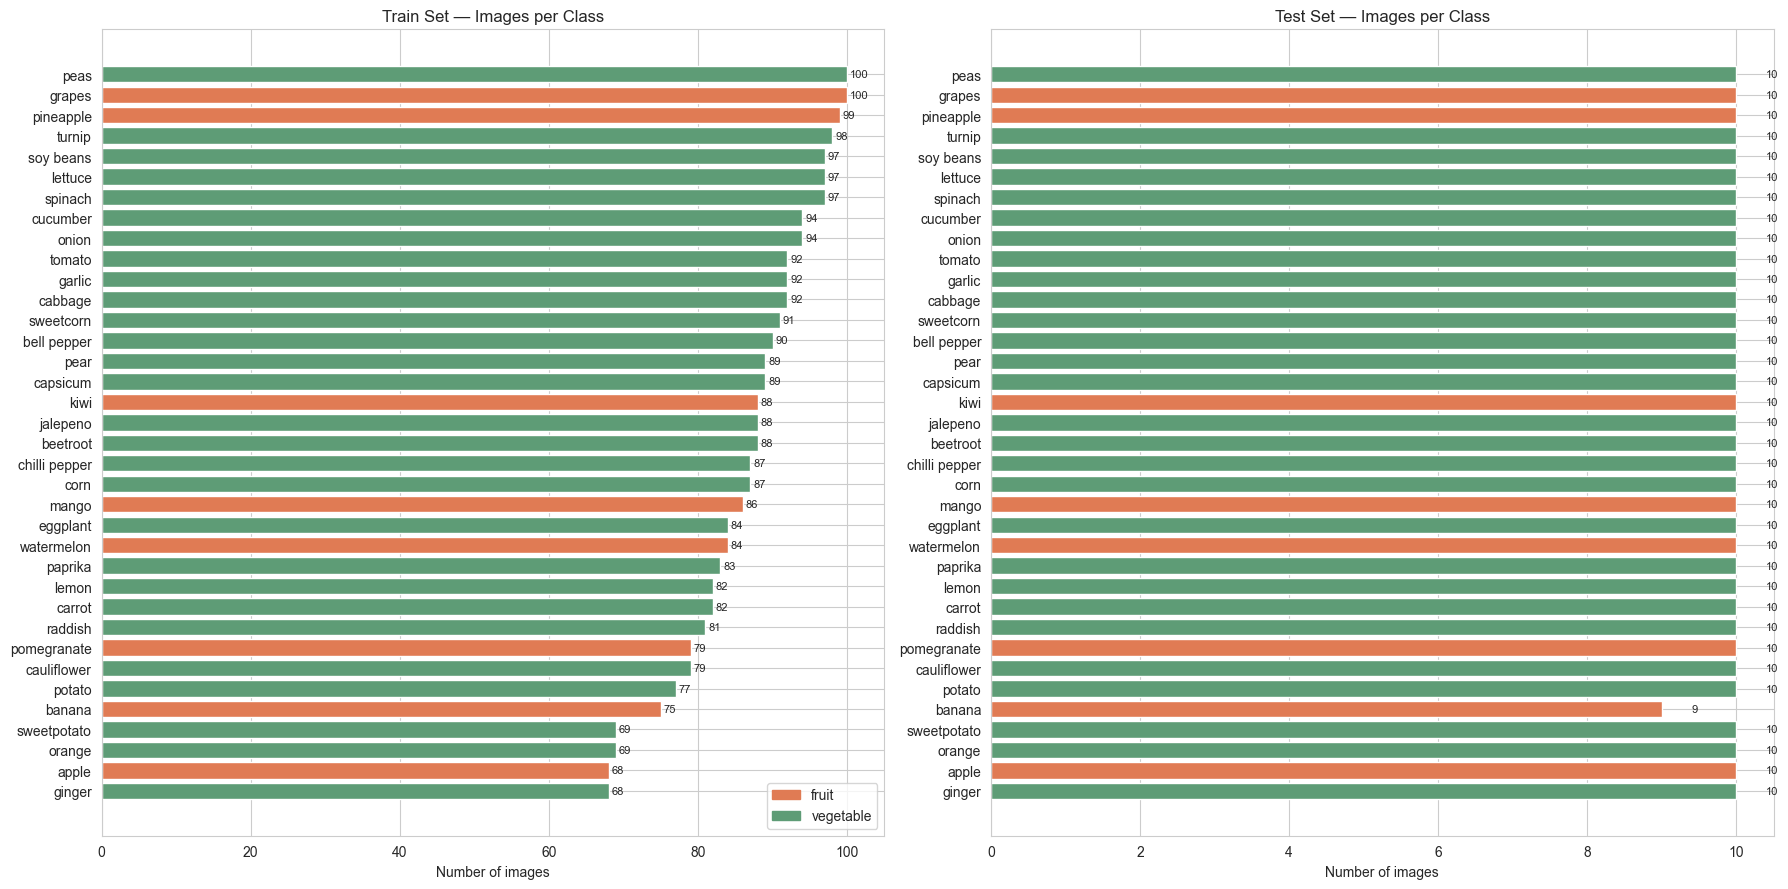

In [7]:
palette = {'fruit': '#e07b54', 'vegetable': '#5e9c76'}
colors  = counts.category.map(palette)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, col, title in zip(axes, ['train', 'test'], ['Train Set', 'Test Set']):
    ax.barh(counts['class'], counts[col], color=colors)
    ax.set_xlabel('Number of images')
    ax.set_title(f'{title} — Images per Class')
    ax.invert_yaxis()
    for i, v in enumerate(counts[col]):
        ax.text(v + 0.4, i, str(v), va='center', fontsize=8)

legend_handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
axes[0].legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
cv      = counts.train.std() / counts.train.mean() * 100
balance = 'well balanced' if cv < 30 else 'consider class weights'

print('=== Train set balance ===')
print(f'Min  : {counts.train.min():>4d}  ({counts.loc[counts.train.idxmin(), "class"]})')
print(f'Max  : {counts.train.max():>4d}  ({counts.loc[counts.train.idxmax(), "class"]})')
print(f'Mean : {counts.train.mean():>7.1f}')
print(f'Std  : {counts.train.std():>7.1f}')
print(f'CV   : {cv:>7.1f}%  ({balance})')

=== Train set balance ===
Min  :   68  (apple)
Max  :  100  (peas)
Mean :    86.5
Std  :     9.2
CV   :    10.6%  (well balanced)


## 4. Sample Images

One training image per class, arranged alphabetically in a 6 x 6 grid.

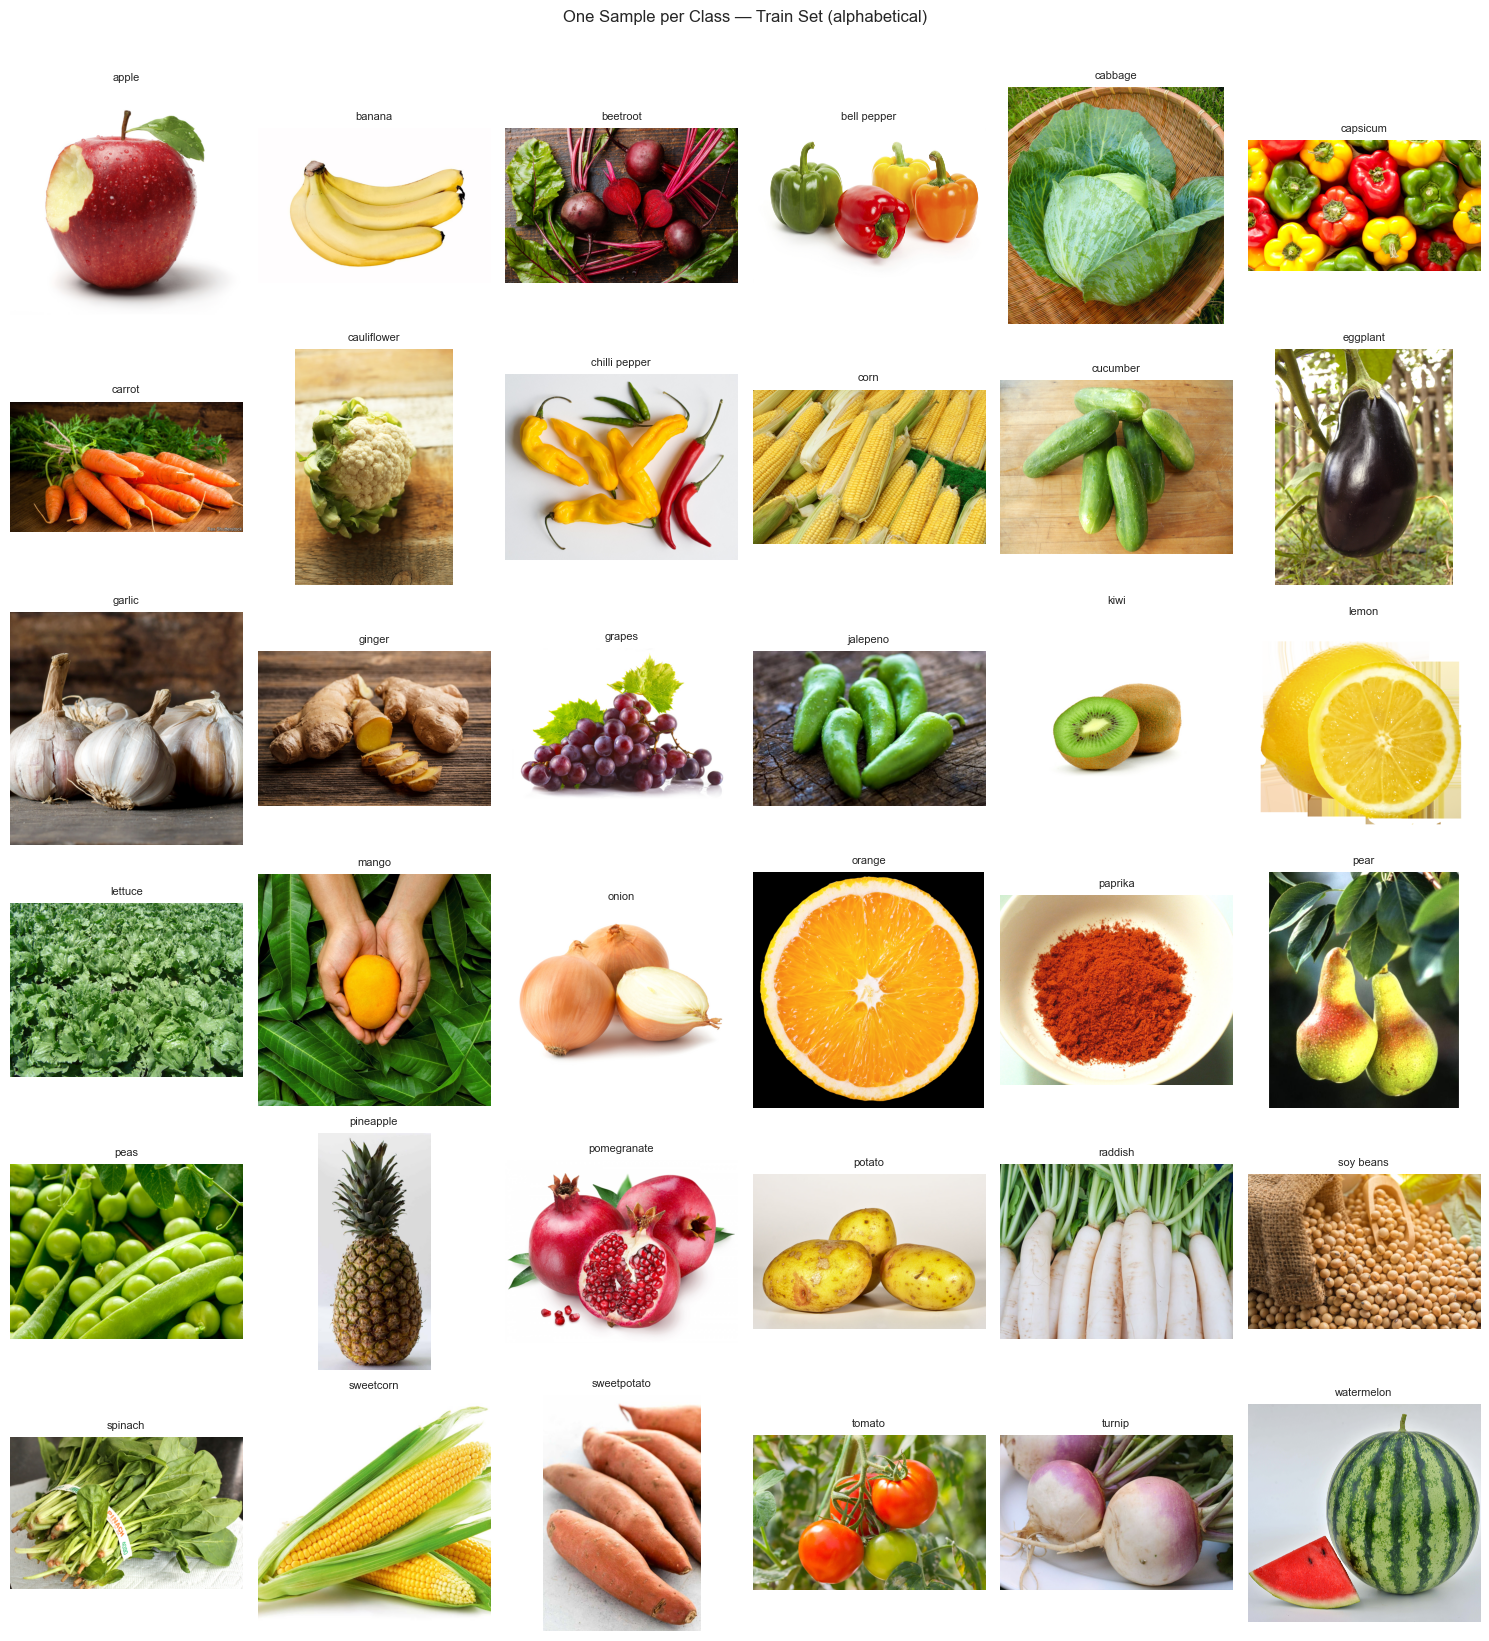

In [9]:
cols = 6
rows = -(-N_CLASSES // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.7))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    path = train_classes[cls]
    imgs = [f for f in path.iterdir() if f.suffix.lower() in IMG_EXTS]
    ax   = axes[i]
    if imgs:
        try:
            ax.imshow(Image.open(imgs[0]).convert('RGB'))
        except Exception:
            ax.text(0.5, 0.5, 'err', ha='center', va='center',
                    transform=ax.transAxes, color='red')
    ax.set_title(cls, fontsize=8)
    ax.axis('off')

for j in range(N_CLASSES, len(axes)):
    axes[j].axis('off')

fig.suptitle('One Sample per Class — Train Set (alphabetical)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Image Statistics

Sampled 540 images (up to 15 per class)
Width  — min: 160, max: 6238, mean: 1492
Height — min: 199, max: 6351, mean: 1251


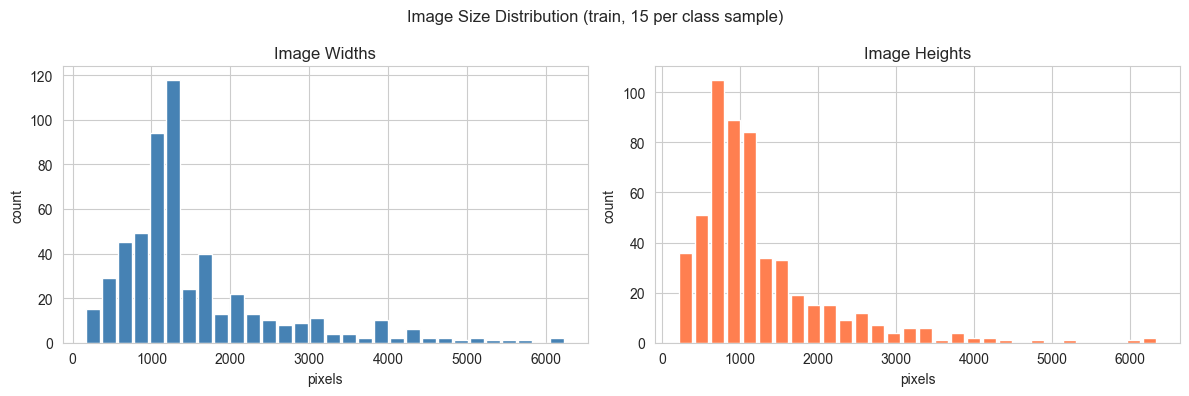

In [10]:
widths, heights = [], []
for path in train_classes.values():
    for f in list(path.iterdir())[:15]:
        if f.suffix.lower() not in IMG_EXTS:
            continue
        try:
            with Image.open(f) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            pass

print(f'Sampled {len(widths)} images (up to 15 per class)')
print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white', rwidth=0.85)
axes[0].set(title='Image Widths',  xlabel='pixels', ylabel='count')
axes[1].hist(heights, bins=30, color='coral',     edgecolor='white', rwidth=0.85)
axes[1].set(title='Image Heights', xlabel='pixels', ylabel='count')
plt.suptitle('Image Size Distribution (train, 15 per class sample)')
plt.tight_layout()
plt.show()

## 6. Data Quality Check

In [11]:
print('Scanning train for corrupted images (header check) ...')
bad = []
for cls, path in train_classes.items():
    for f in path.iterdir():
        if f.suffix.lower() not in IMG_EXTS:
            continue
        try:
            with Image.open(f) as img:
                img.verify()
        except Exception as e:
            bad.append((cls, f.name, str(e)))

print(f'Corrupted files found: {len(bad)}')
for cls, fname, err in bad:
    print(f'  [{cls}] {fname} — {err}')

Scanning train for corrupted images (header check) ...


Corrupted files found: 0


In [12]:
def ext_counts(class_dirs: dict) -> dict:
    c = Counter()
    for path in class_dirs.values():
        for f in path.iterdir():
            c[f.suffix.lower()] += 1
    return dict(c.most_common())

print('Train extensions:', ext_counts(train_classes))
print('Test  extensions:', ext_counts(test_classes))

Train extensions: {'.jpg': 2855, '.png': 201, '.jpeg': 59}
Test  extensions: {'.jpg': 340, '.png': 11, '.jpeg': 8}


## 7. Data Loading Strategy

### The nested-directory problem

`ImageDataGenerator.flow_from_directory` expects a **flat** structure:
```
root/class_a/img.jpg
root/class_b/img.jpg
```
Pointing it at `train/` gives two classes (`fruit`, `vegetable`) — not 36.

### Solution used in notebooks 01 / 02 / 03

Build a flat file list from the nested tree, then feed it into a `tf.data.Dataset`.
The two functions below are the **shared data-loading pattern** for all model notebooks.

In [13]:
def build_file_list(root: Path, class_to_idx: dict) -> tuple:
    """Return (file_path_strings, int_labels) from the nested fruit/veg structure."""
    paths, labels = [], []
    for cat_dir in sorted(root.iterdir()):
        if not cat_dir.is_dir():
            continue
        for cls_dir in sorted(cat_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            cls = cls_dir.name.lower()
            if cls not in class_to_idx:
                continue
            idx = class_to_idx[cls]
            for f in cls_dir.iterdir():
                if f.suffix.lower() in IMG_EXTS:
                    paths.append(str(f))
                    labels.append(idx)
    return paths, labels


def make_tf_dataset(file_paths, int_labels, n_classes,
                    img_size=(224, 224), batch_size=32,
                    augment=False, shuffle=True, seed=42):
    """Batched tf.data.Dataset with preprocessing and optional augmentation."""

    def load(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0
        return img, tf.one_hot(label, n_classes)

    def augment_fn(img, label):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
        img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((file_paths, int_labels))
    if shuffle:
        ds = ds.shuffle(len(file_paths), seed=seed)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [14]:
all_paths, all_labels = build_file_list(TRAIN_ROOT, CLASS_TO_IDX)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2, stratify=all_labels, random_state=42
)

test_paths, test_labels = build_file_list(TEST_ROOT, CLASS_TO_IDX)

print(f'All train images : {len(all_paths)}')
print(f'Train split      : {len(train_paths)}')
print(f'Val   split      : {len(val_paths)}')
print(f'Test             : {len(test_paths)}')

All train images : 3115
Train split      : 2492
Val   split      : 623
Test             : 359


In [15]:
BATCH_SIZE = 32

sample_ds = make_tf_dataset(
    train_paths[:200], train_labels[:200], N_CLASSES,
    img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=False
)

for imgs, lbls in sample_ds.take(1):
    print(f'Batch images shape : {imgs.shape}')
    print(f'Batch labels shape : {lbls.shape}')
    print(f'Pixel range        : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')
    print(f'Sample class idxs  : {np.argmax(lbls.numpy(), axis=1)[:8].tolist()}')

Batch images shape : (32, 224, 224, 3)
Batch labels shape : (32, 36)
Pixel range        : [0.000, 1.000]
Sample class idxs  : [13, 0, 0, 27, 8, 10, 25, 24]


## Summary

| Item | Value |
|------|-------|
| Total classes | 36 (8 fruit + 28 vegetable in `train/`) |
| Train images | 3,115 |
| Test images | ~359 |
| Train / Val split | 80 / 20 stratified, `random_state=42` |
| Target input size | 224 x 224 x 3 |
| Pixel normalisation | / 255 -> [0, 1] |

### Checklist for notebooks 01 / 02 / 03

- Copy `build_file_list` and `make_tf_dataset` from this notebook into each model notebook.
- Use the same `CLASS_NAMES` list (alphabetically sorted) so integer labels are consistent across all three.
- Do **not** use the `validation/` folder.
- Report final metrics on `test_ds` (the held-out test set), not the validation split.
- In `04_comparison.ipynb`, load all three saved models and evaluate on the same `test_ds`.